# Part 2 — Decision Tree

This notebook is a readable entry point for the tested Python modules. Run from the repository root. Saved formal results are already included. Hyperparameters and fitted models were frozen before this runner evaluated the final test set. See `part2/README.md` for Windows setup.

1. Use the supplied common data and Part 4 development/CV membership.
2. Select maximum depth / minimum leaf size by five-fold AP.
3. Explain overfitting and actual tree rules.
4. Evaluate at the fixed 0.5 threshold on the common final test set.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display, Markdown
ROOT = Path.cwd()
assert (ROOT / "part2/experiment.py").exists(), "Open the repository root first"
OUT = ROOT / "results/decision_tree"
protocol = json.loads((OUT / "protocol_frozen.json").read_text())
print("Selected parameters:", protocol["Selected_parameters"])
print("Selection metric:", protocol["Selection_metric"])
print(protocol["Part4_membership_checks"])

Selected parameters: {'max_depth': None, 'min_samples_leaf': 100}
Selection metric: average_precision
{'development_membership.csv': 'Exact membership and row order verified against Part 4', 'cv_membership.csv': 'Exact membership and row order verified against Part 4'}


## 1. Parameter search

Five-fold scores are for selection; test metrics below are separate. The fitting set has 18,000 clients. The 6,000 validation clients are not added to final training, matching Part 4.

,Max_depth,Min_samples_leaf,Mean_fit_AP,Mean_CV_AP,SD_CV_AP
20,Unlimited,100,0.584506,0.530725,0.018517
17,8,100,0.569281,0.529029,0.020916
14,6,100,0.552805,0.524536,0.019455
13,6,20,0.557665,0.522045,0.011371
11,5,100,0.536505,0.519773,0.017871
10,5,20,0.537142,0.516323,0.012816
16,8,20,0.599649,0.516049,0.013006
12,6,1,0.562197,0.510682,0.010538
9,5,1,0.537190,0.508291,0.011336
8,4,100,0.512294,0.502889,0.017722


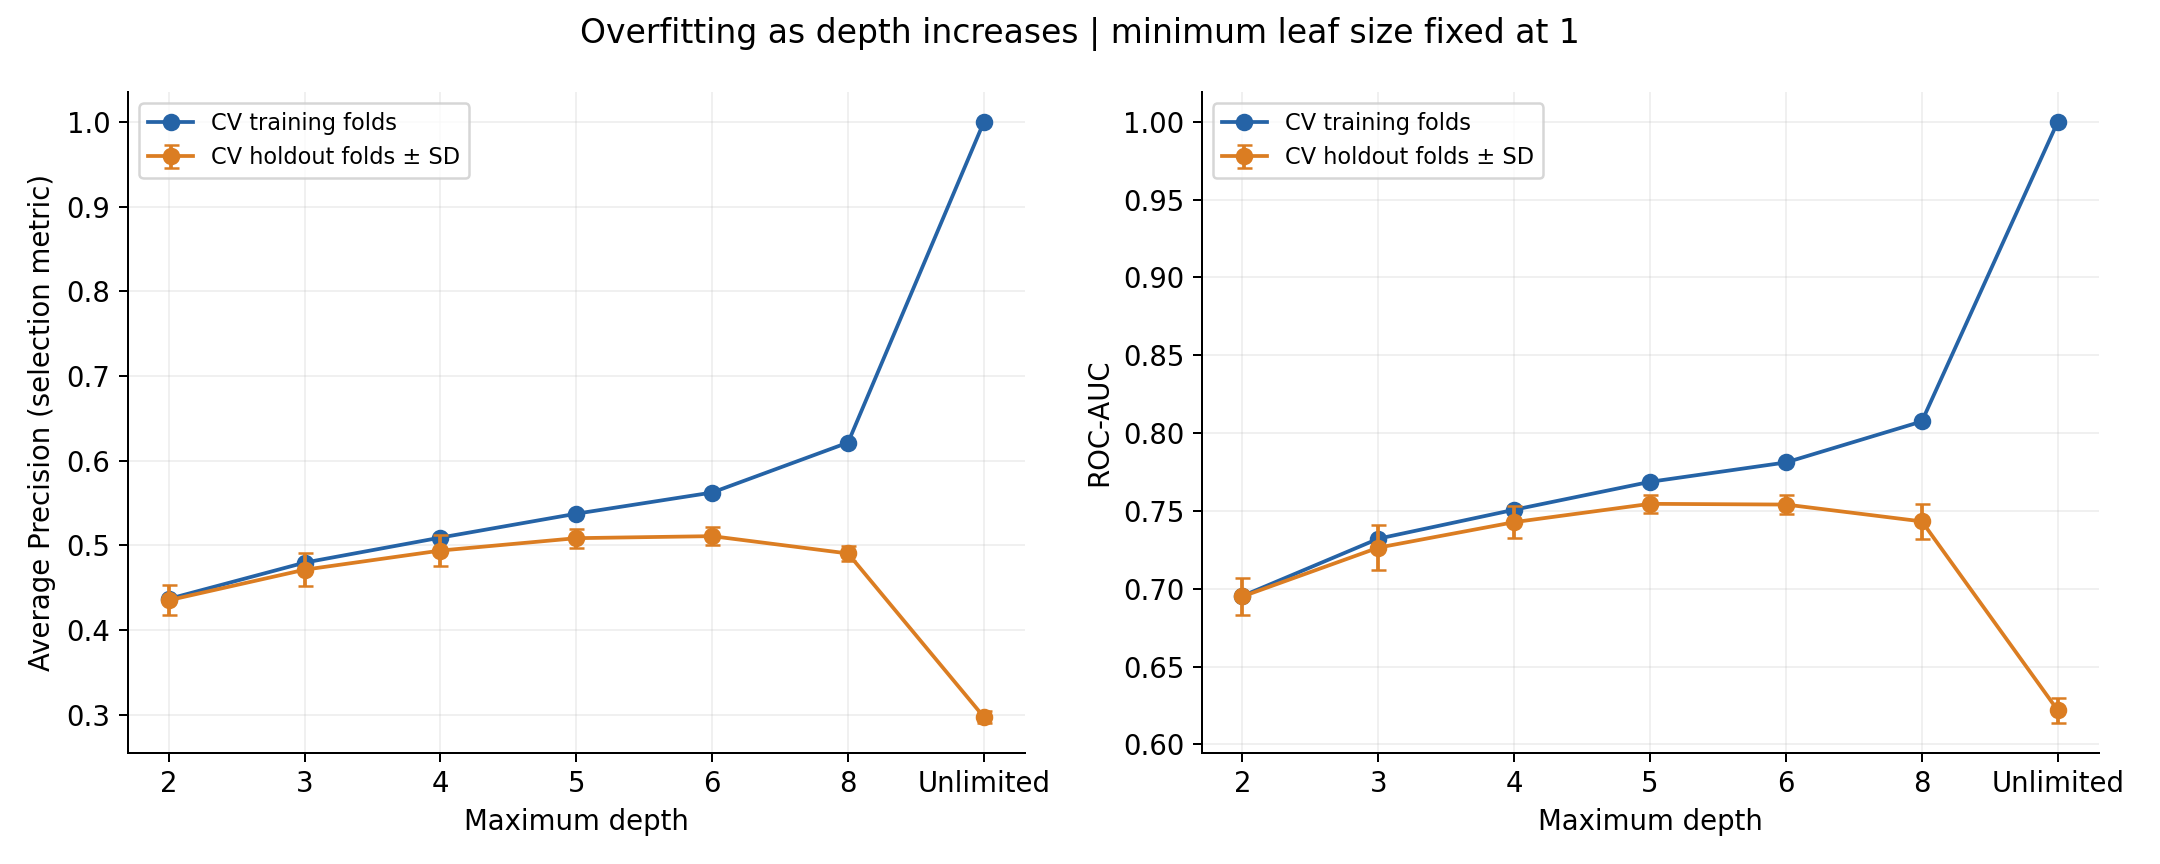

In [2]:
cv = pd.read_csv(OUT / "cv_results.csv")
display(cv.sort_values("Mean_CV_AP", ascending=False)[["Max_depth", "Min_samples_leaf", "Mean_fit_AP", "Mean_CV_AP", "SD_CV_AP"]])
display(Image(filename=str(OUT / "figures/01_overfitting.png")))

## 2. Actual rules

The figure is truncated. Counts describe fitting observations, not externally validated probabilities. Rule labels use the team probability >=0.5 convention.

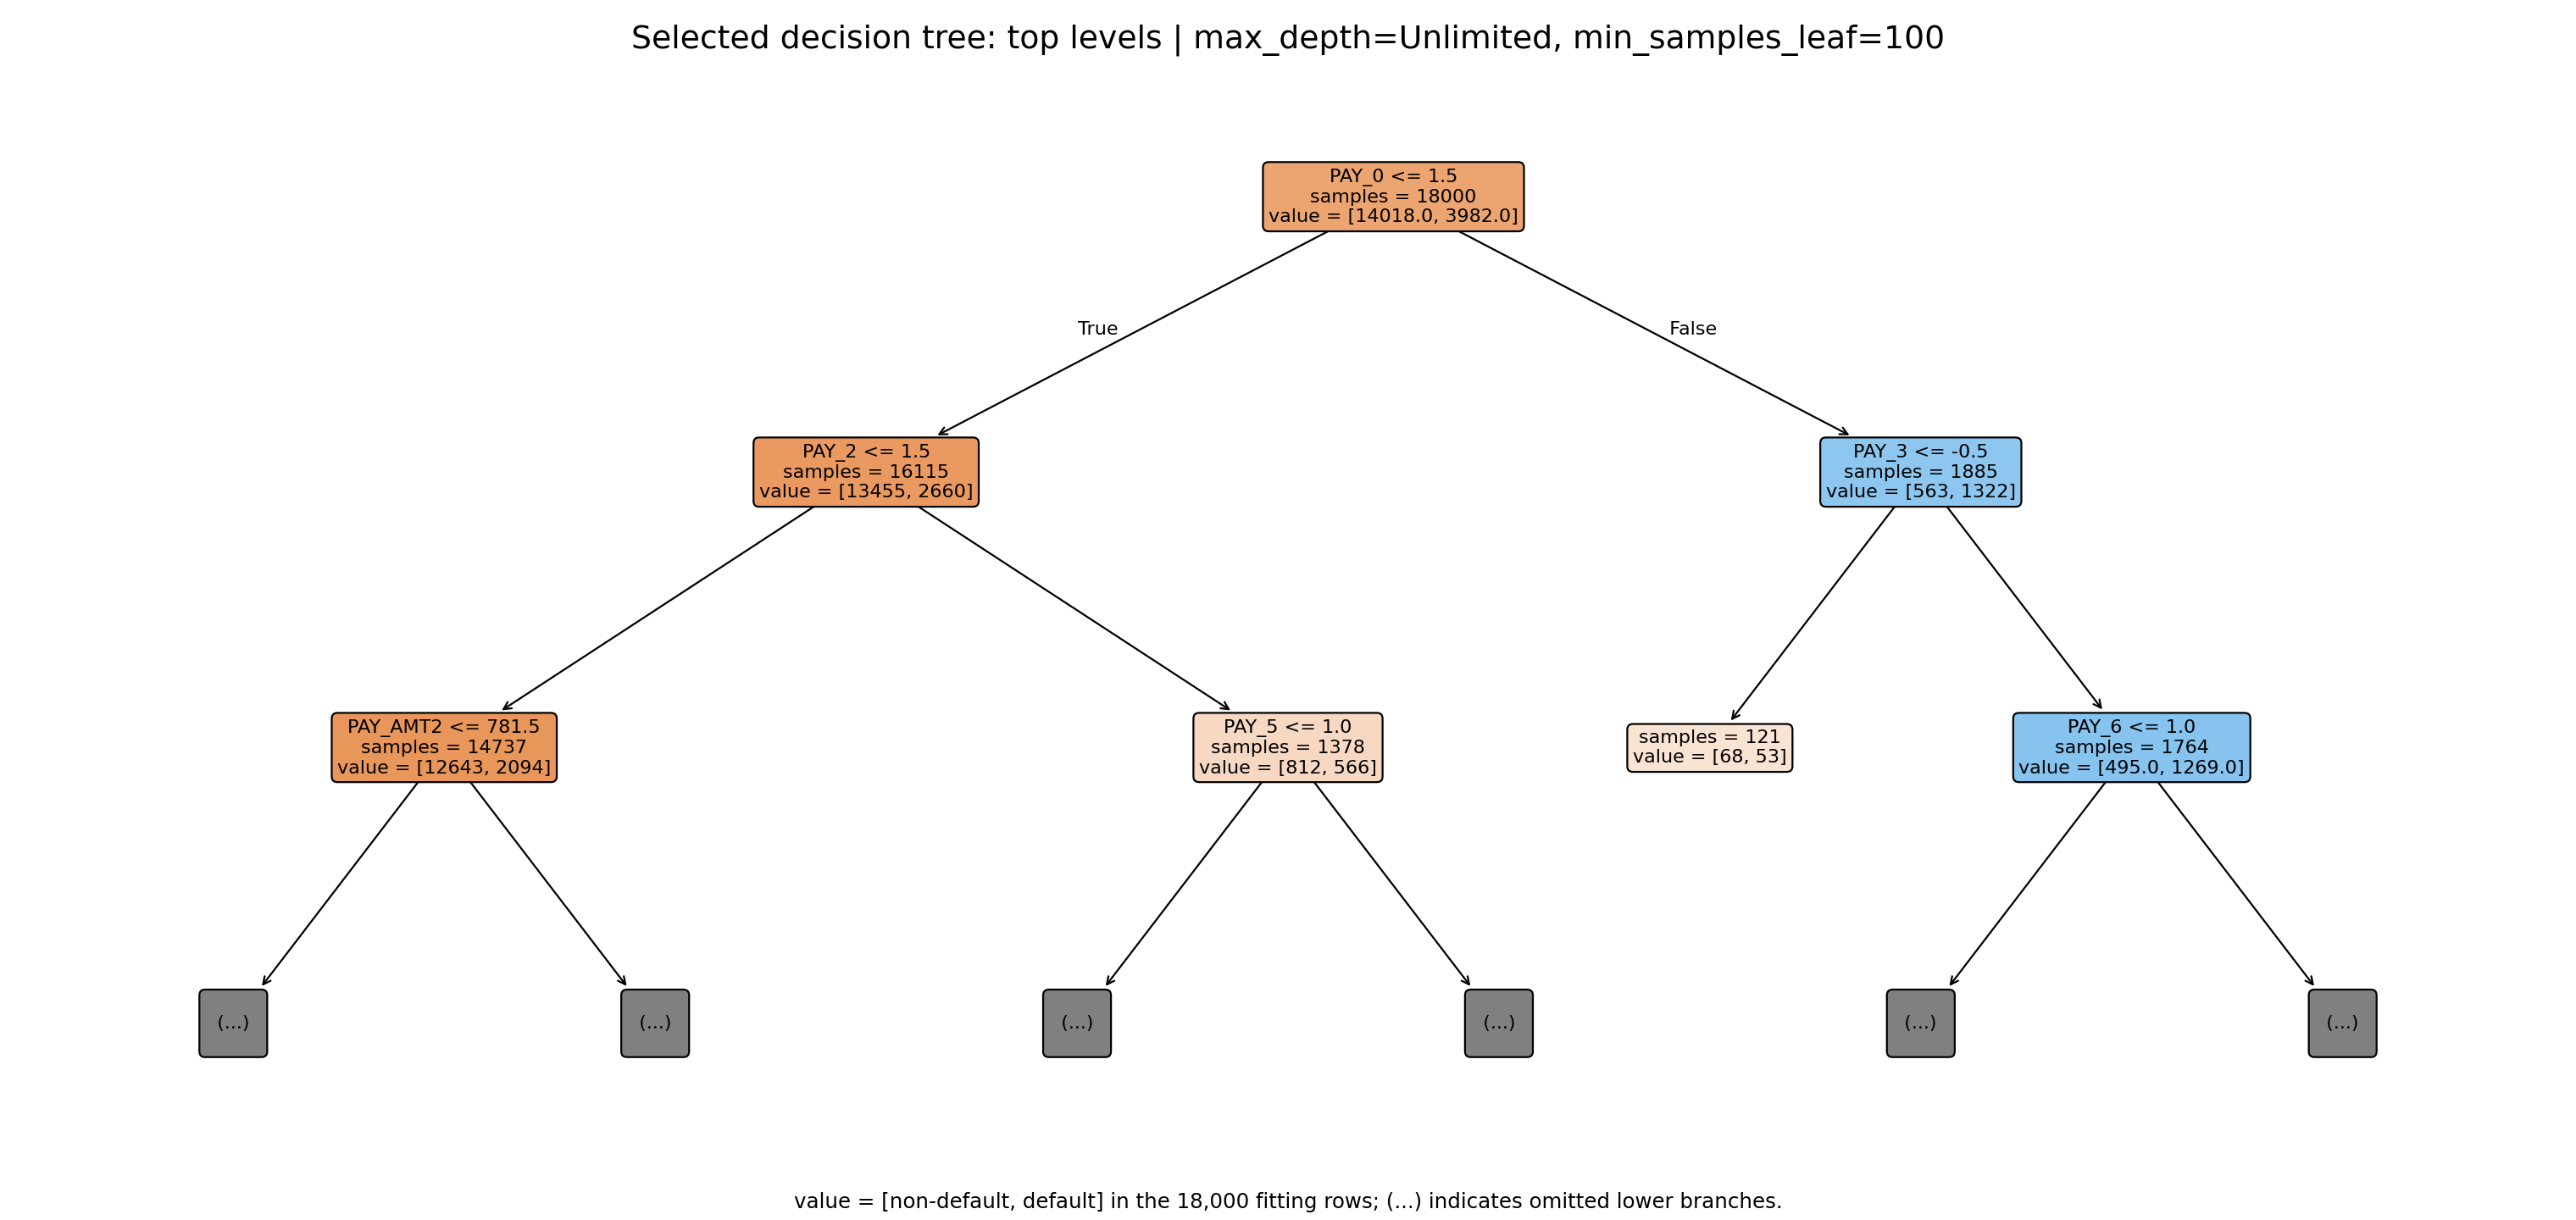

,Leaf,Conditions,Fit_samples,Fit_defaults,Fit_default_rate,Predicted_default_at_0.5
0,174,PAY_0 <= 1.5 AND PAY_2 <= 1.5 AND PAY_AMT2 > 7...,252,0,0.000000,0
1,250,PAY_0 > 1.5 AND PAY_3 > -0.5 AND PAY_6 <= 1 AN...,177,127,0.717514,1


In [3]:
display(Image(filename=str(OUT / "figures/02_tree_top_levels.png")))
display(pd.read_csv(OUT / "representative_rules.csv"))

## 3. Final test evaluation

No parameter changes are made using these results. Precision, recall and F1 refer to default=1. AP means Average Precision, not trapezoidal PR-AUC.

,Model,AP,ROC-AUC,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,Baseline Decision Tree,0.284267,0.607552,0.721333,0.378264,0.403919,0.390671,3792,881,791,536
1,Tuned Decision Tree,0.522092,0.753845,0.816833,0.658333,0.357197,0.463117,4427,246,853,474


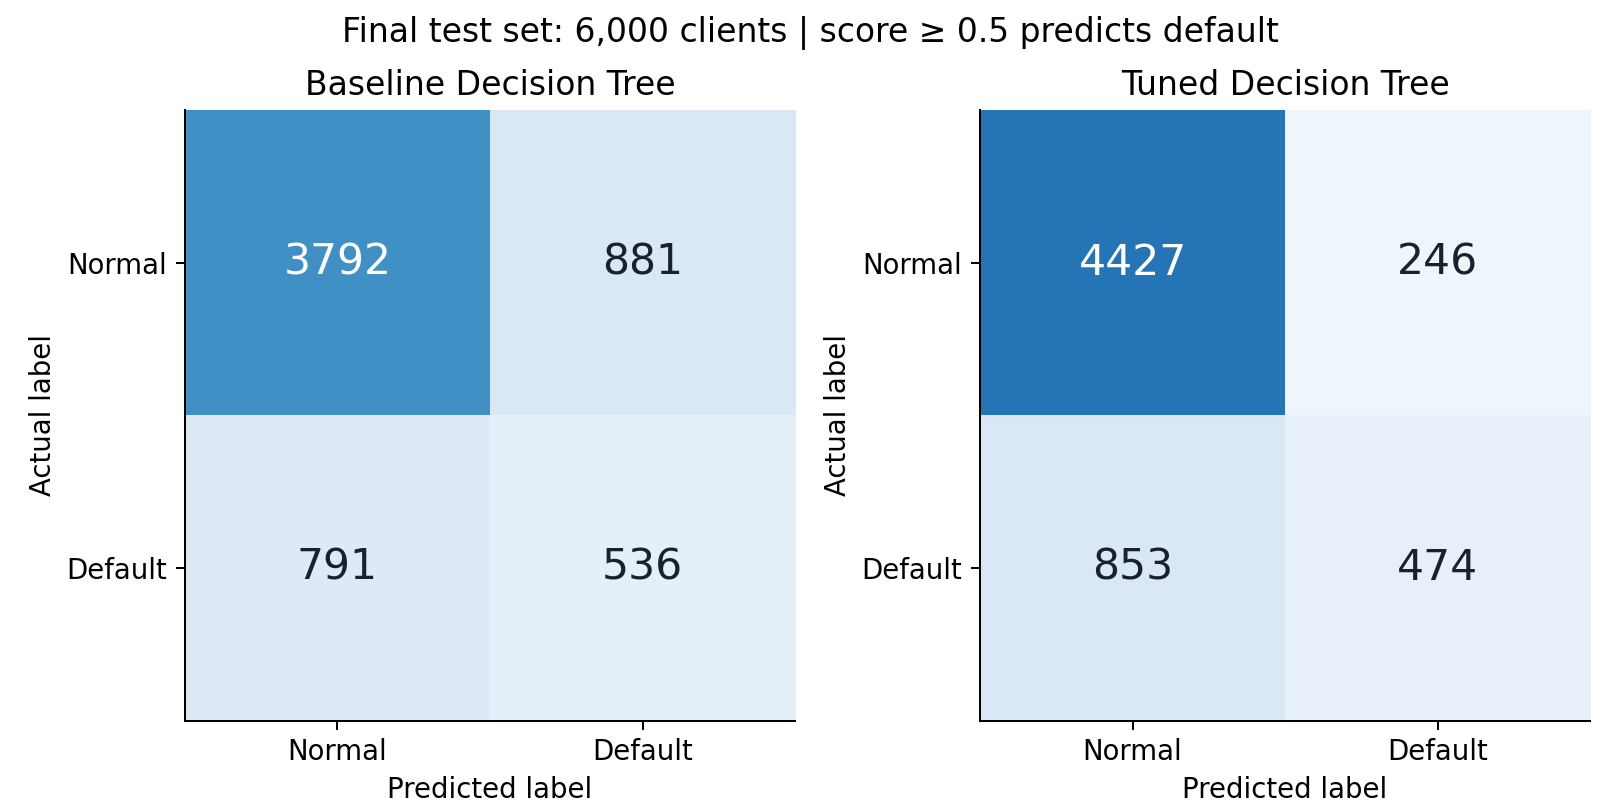

In [4]:
display(pd.read_csv(OUT / "test_metrics.csv")[["Model","AP","ROC-AUC","Accuracy","Precision","Recall","F1","TN","FP","FN","TP"]])
display(Image(filename=str(OUT / "figures/03_test_confusion.png")))

## 4. Report text

In [5]:
display(Markdown((OUT / "report_en.md").read_text(encoding="utf-8")))

# Decision Tree: Methods and Findings

## Methods
We used the team-supplied cleaned data and fixed 24,000/6,000 training–test split. To match Part 4, the development data were further split into 18,000 fitting and 6,000 validation observations. The fitting/validation membership and five stratified cross-validation folds were verified against Part 4's saved row-level files. SEX, EDUCATION and MARRIAGE were one-hot encoded within each training fold; other features retained their cleaned numeric values. The row identifier and outcome were excluded from predictors.

An unrestricted decision tree was compared with 21 combinations of maximum depth (2, 3, 4, 5, 6, 8, unlimited) and minimum leaf size (1, 20, 100). Parameters were selected by mean five-fold Average Precision (AP); ROC-AUC was also recorded. The selected setting was maximum depth **unlimited (None)** and minimum leaf size **100**. Both models were fitted on the 18,000 fitting observations and kept unchanged for validation and final test evaluation. Consistent with Part 4, no refit used the validation rows. The fixed classification rule was probability ≥0.5; thresholds were not tuned in this contribution.

## Overfitting and final evaluation
The unrestricted model's mean CV training AP was 1.0000, versus 0.2970 on CV holdout folds. For the selected tree, the corresponding values were 0.5845 and 0.5307 (holdout-fold SD 0.0185). The reduced training–validation gap supports controlling tree complexity. The selected tree has no explicit depth cap, but its minimum leaf size still limits complexity: the fitted tree has 18 levels of splits and 134 leaves. The depth curve fixes minimum leaf size at 1 and isolates the effect of depth; it is distinct from the joint parameter search.

| Model | AP | ROC-AUC | Accuracy | Precision | Recall | F1 |
| --- | --- | --- | --- | --- | --- | --- |
| Baseline Decision Tree | 0.2843 | 0.6076 | 0.7213 | 0.3783 | 0.4039 | 0.3907 |
| Tuned Decision Tree | 0.5221 | 0.7538 | 0.8168 | 0.6583 | 0.3572 | 0.4631 |

The final test results above use the same 6,000 clients for both trees. At threshold 0.5, the selected tree produced 474 true positives, 853 false negatives, 246 false positives and 4427 true negatives. AP and ROC-AUC assess ranking; accuracy and the default-class precision/recall/F1 use the fixed threshold. All-negative prediction would achieve 77.88% accuracy, illustrating why accuracy alone is insufficient.

## Interpretable rules
The root split was `PAY_0 <= 1.5`. Within the fitting data, the default proportions were 16.51% on the left and 70.13% on the right. These are observed node proportions, not causal effects or externally validated individual probabilities. The top-level figure is truncated: its intermediate nodes must not be described as final predictions. Exact root-to-leaf rules, support counts and default fractions are recorded in `leaf_rules.csv`; `representative_rules.csv` contains the largest-support leaf for each predicted class present.

## Limitations and integration
Hyperparameter selection uses CV scores and can introduce selection optimism; final claims therefore use held-out test metrics. The test data were first loaded by this runner after parameters and fitted models were frozen. Other team members' test results were already visible; this is not a new globally untouched dataset. No additional parameter changes were made after this decision-tree test evaluation. No confidence intervals or significance claims are supplied. The historical Taiwan sample and retained identical feature vectors limit generalization claims. Model rules describe associations, not causal explanations.

The integration now includes verified RF results and a separately labelled post-hoc logistic supplement. Legacy logistic CSVs remain unverified: their original training procedure and PR-AUC definition were not recoverable. The complete comparison and submission materials are in results/final/ and submission/. Shared splits do not imply identical search budgets or globally unseen historical test data.

## Sources
- Team repository, reviewed base commit `0188f4a0df4e46140c8aa8ebfef4ba4a54403255`: https://github.com/IcantFind-a-username/-SC6122-Group5-Credit-Default
- UCI dataset: Yeh, I. (2009). Default of Credit Card Clients. https://doi.org/10.24432/C55S3H (CC BY 4.0).
- Decision-tree implementation: https://scikit-learn.org/stable/modules/tree.html


## Optional: reproduce in a new directory

Run these commands in a terminal using the same Python environment. This recomputes the frozen workflow, not a new tuning exercise based on test results.

```bash
python -m part2.experiment --output-dir results/decision_tree_reproduction
python -m part2.plots_and_report --output-dir results/decision_tree_reproduction
```

Then change `OUT` above to that reproduction directory. The command refuses to overwrite a frozen run.